### Data download

This notebook is adapted from the original CalAdapt repository and downloads CalAdapt data for a specific National Park. 

In [1]:
import intake
import geopandas as gpd
import xarray as xr
import rioxarray          # noqa: F401 – registers the .rio accessor
import numpy as np
from pathlib import Path

cat = intake.open_esm_datastore('https://cadcat.s3.amazonaws.com/cae-collection.json')
print("Catalog loaded.")


/opt/conda/envs/climate_futures/lib/python3.12/site-packages/intake_esm/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


Catalog loaded.


In [2]:
# ── Load boundary shapefiles ───────────────────────────────────────────────────
boundaries_dir = Path('/workspaces/climate_futures/boundaries')

parks = {
   # 'jotr': gpd.read_file(boundaries_dir / 'jotr.shp'),
   # 'moja': gpd.read_file(boundaries_dir / 'moja.shp'),
    'deva': gpd.read_file(boundaries_dir / 'deva.shp'),
}

for name, gdf in parks.items():
    print(f"{name}: CRS={gdf.crs}  |  bounds={gdf.total_bounds.round(4)}")


deva: CRS=PROJCS["USA_Contiguous_Albers_Equal_Area_Conic_USGS_version",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",23],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",29.5],PARAMETER["standard_parallel_2",45.5],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","102039"]]  |  bounds=[-1919353.4136  1590419.1622 -1788655.9861  1806700.7697]


### Helper functions

In [3]:

def load_loca2(cat, source_id, member_id, experiment_id, variable_id):
    """Query the CAE catalog for LOCA2 daily data; return dataset dict."""
    query = {
        'activity_id':   'LOCA2',
        'source_id':     source_id,
        'member_id':     member_id,
        'experiment_id': experiment_id,
        'variable_id':   variable_id,
        'table_id':      'day',
        'grid_label':    'd03',
    }
    subset = cat.search(require_all_on=['source_id'], **query)
    return subset.to_dataset_dict(
        xarray_open_kwargs={'consolidated': True},
        storage_options={'anon': True},
    )


def crop_to_boundary(ds, variable, boundary):
    """Clip an xarray Dataset variable to a GeoDataFrame boundary."""
    da = ds[variable].rio.set_spatial_dims(x_dim='lon', y_dim='lat')
    da = da.rio.write_crs('EPSG:4326', inplace=True)
    if da.rio.crs != boundary.crs:
        boundary = boundary.to_crs(da.rio.crs)
    return da.rio.clip(boundary.geometry.values, boundary.crs, drop=True, all_touched=True)


def save_nc(da, out_path):
    """Write a DataArray to NetCDF, creating parent directories as needed."""
    out_path.parent.mkdir(parents=True, exist_ok=True)
    da.to_netcdf(out_path)
    print(f"    ✓ saved → {out_path}")


print("Helper functions defined.")


Helper functions defined.


### Retrieve data
Naming convention mirrors ISIMIP: `{source_id}_{member_id}_loca2_{experiment_id}_{variable}_{park}_monthly.nc`

In [ ]:

# member_id overrides for models that don't use r1i1p1f1
MEMBER_IDS = {
    'CNRM-ESM2-1':     'r1i1p1f2',
    'HadGEM3-GC31-LL': 'r1i1p1f3',
}

source_ids = [
    # 'GFDL-ESM4',       # already processed
    'ACCESS-CM2',
    'CESM2-LENS',
    'CNRM-ESM2-1',
    'EC-Earth3',
    'EC-Earth3-Veg',
    'FGOALS-g3',
    'HadGEM3-GC31-LL',  # UK Met Office physical model
    'HadGEM3-GC31-LL',
    'INM-CM5-0',
    'IPSL-CM6A-LR',
    'KACE-1-0-G',
    'MIROC6',
    'MPI-ESM1-2-HR',
    'MRI-ESM2-0',
    'TaiESM1',
    'CESM2',
]

experiments  = ['historical', 'ssp245', 'ssp370', 'ssp585']
output_base  = Path('caladapt')

for source_id in source_ids:
    member_id = MEMBER_IDS.get(source_id, 'r1i1p1f1')
    print(f"\n{'#'*60}")
    print(f"Model: {source_id}  ({member_id})")
    print(f"{'#'*60}")

    for experiment_id in experiments:
        print(f"\n  {'='*54}")
        print(f"  Experiment: {experiment_id}")
        print(f"  {'='*54}")

        for park_name, boundary in parks.items():
            print(f"\n    Park: {park_name}")

            stem = f'{source_id.lower()}_{member_id}_loca2_{experiment_id}'

            # ── Precipitation (daily → monthly sum) ────────────────────────
            try:
                print("    [pr] Fetching daily data…")
                dsets = load_loca2(cat, source_id, member_id, experiment_id, 'pr')
                ds_pr = dsets[list(dsets)[0]]

                print("    [pr] Cropping to boundary…")
                da_pr = crop_to_boundary(ds_pr, 'pr', boundary)

                print("    [pr] Monthly sum…")
                da_pr_monthly = da_pr.resample(time='MS').sum(skipna=False)
                da_pr_monthly.attrs.update(ds_pr['pr'].attrs)
                da_pr_monthly.name = 'pr'

                save_nc(da_pr_monthly, output_base / f'{stem}_pr_{park_name}_monthly.nc')

                ds_pr.close()

            except Exception as exc:
                print(f"    [pr] ERROR: {exc}")

            # ── Temperature: tas = (tasmax + tasmin) / 2, monthly mean ────
            try:
                print("    [tas] Fetching daily tasmax…")
                dsets_max = load_loca2(cat, source_id, member_id, experiment_id, 'tasmax')
                ds_tasmax = dsets_max[list(dsets_max)[0]]

                print("    [tas] Fetching daily tasmin…")
                dsets_min = load_loca2(cat, source_id, member_id, experiment_id, 'tasmin')
                ds_tasmin = dsets_min[list(dsets_min)[0]]

                print("    [tas] Computing daily tas = (tasmax + tasmin) / 2…")
                da_tas = (ds_tasmax['tasmax'] + ds_tasmin['tasmin']) / 2.0
                da_tas.name = 'tas'
                da_tas.attrs = {
                    **ds_tasmax['tasmax'].attrs,
                    'long_name': 'Near-Surface Air Temperature',
                    'comment':   'Daily mean estimated as (tasmax + tasmin) / 2',
                }

                print("    [tas] Cropping to boundary…")
                da_tas_clipped = crop_to_boundary(da_tas.to_dataset(name='tas'), 'tas', boundary)

                print("    [tas] Monthly mean…")
                da_tas_monthly = da_tas_clipped.resample(time='MS').mean(skipna=False)
                da_tas_monthly.name = 'tas'

                save_nc(da_tas_monthly, output_base / f'{stem}_tas_{park_name}_monthly.nc')

                da_tas.close()
                ds_tasmax.close()
                ds_tasmin.close()

            except Exception as exc:
                print(f"    [tas] ERROR: {exc}")

print("\n✅ All done!")



############################################################
Model: ACCESS-CM2  (r1i1p1f1)
############################################################

  Experiment: historical

    Park: deva
    [pr] Fetching daily data…

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:01&lt;00:00]</div>

    [pr] Cropping to boundary…
    [pr] Monthly sum…
    ✓ saved → ../caladapt/access-cm2_r1i1p1f1_loca2_historical_pr_deva_monthly.nc
    [pr] ERROR: 'dict' object has no attribute 'close'
    [tas] Fetching daily tasmax…

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:00&lt;00:00]</div>

    [tas] Fetching daily tasmin…

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


...

<div><progress max="1" value="1"></progress> 100.00% [1/1 00:00&lt;00:00]</div>

    [tas] Fetching daily tasmin…

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


<div><progress max="1" value="1"></progress> 100.00% [1/1 00:00&lt;00:00]</div>

    [tas] Computing daily tas = (tasmax + tasmin) / 2…
    [tas] Cropping to boundary…
    [tas] Monthly mean…


KeyboardInterrupt: 

NameError: name 'output_base' is not defined

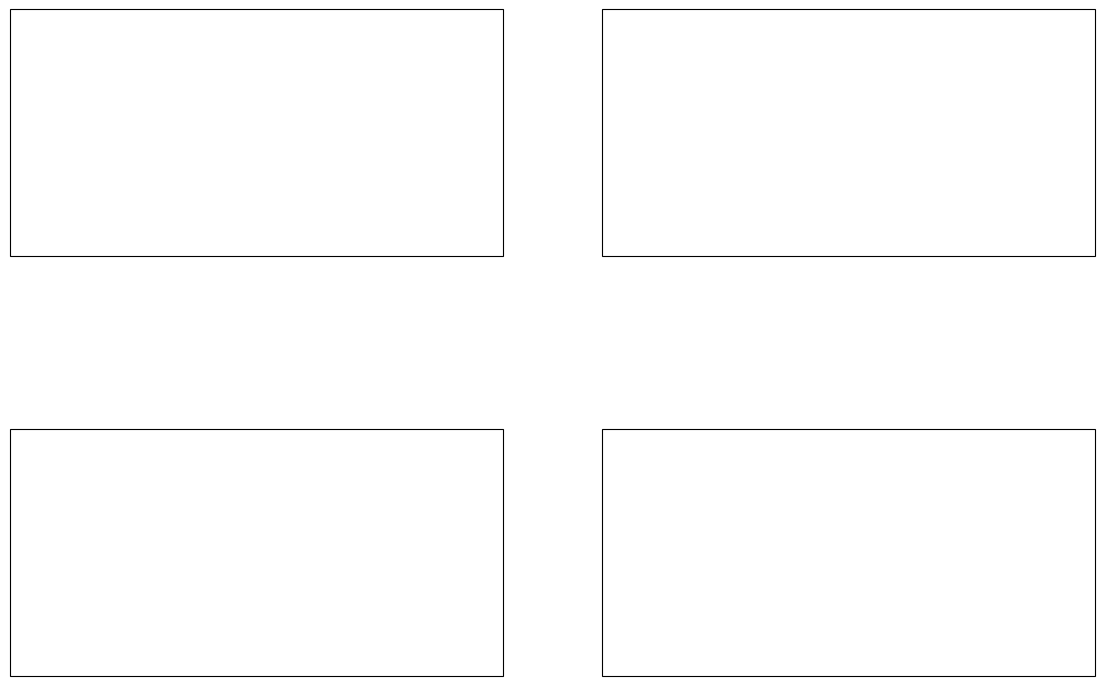

In [1]:

# ── Verification: plot a time slice for each park & variable ──────────────────
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

check_experiment = 'historical'
check_time       = '1990-01'   # any YYYY-MM present in the data

fig, axes = plt.subplots(
    nrows=2, ncols=2,
    figsize=(14, 10),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

configs = [
    ('pr',  'jotr', 'Blues',    'Precipitation (mm/month)'),
    ('pr',  'moja', 'Blues',    'Precipitation (mm/month)'),
    ('tas', 'jotr', 'RdYlBu_r', 'Temperature (K)'),
    ('tas', 'moja', 'RdYlBu_r', 'Temperature (K)'),
]

for ax, (var, park, cmap, label) in zip(axes.flat, configs):
    fpath = output_base / f'{source_id.lower()}_{member_id}_loca2_{check_experiment}_{var}_{park}_monthly.nc'
    ds = xr.open_dataset(fpath)
    # .squeeze() drops the residual size-1 time dim so values are 2-D (lat, lon)
    da = ds[var].sel(time=check_time, method='nearest').squeeze()

    im = ax.pcolormesh(
        da.lon, da.lat, da.values,
        cmap=cmap, transform=ccrs.PlateCarree(),
    )

    # Overlay park boundary
    parks[park].boundary.plot(ax=ax, color='black', linewidth=1, transform=ccrs.PlateCarree())

    # Cartopy features
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='grey')
    ax.coastlines(resolution='10m', linewidth=0.5)
    ax.set_extent([
        float(da.lon.min()) - 0.5, float(da.lon.max()) + 0.5,
        float(da.lat.min()) - 0.5, float(da.lat.max()) + 0.5,
    ])

    plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02, label=label)
    ax.set_title(f'{var.upper()} | {park.upper()} | {check_time}\nmin={float(da.min()):.2f}  mean={float(da.mean()):.2f}  max={float(da.max()):.2f}')
    ds.close()

plt.suptitle(f'LOCA2 {source_id} {check_experiment} — sanity check', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [5]:
# ── Aggregate monthly → yearly ─────────────────────────────────────────────────
# pr:  yearly sum   (total annual precipitation)
# tas: yearly mean  (mean annual temperature)
from pathlib import Path
import xarray as xr

output_base = Path('../caladapt')
source_id   = 'GFDL-ESM4'
member_id   = 'r1i1p1f1'

agg = {'pr': 'sum', 'tas': 'mean'}

monthly_files = sorted(output_base.glob('*_monthly.nc'))
print(f"Found {len(monthly_files)} monthly files\n")

for fpath in monthly_files:
    # derive variable from filename stem, e.g. ..._pr_jotr_monthly.nc → 'pr'
    parts = fpath.stem.split('_')          # [..., var, park, 'monthly']
    var   = parts[-3]

    if var not in agg:
        print(f"  skipping {fpath.name} (unknown variable '{var}')")
        continue

    ds = xr.open_dataset(fpath)
    da = ds[var]

    if agg[var] == 'sum':
        da_yearly = da.resample(time='YS').sum(skipna=False)
    else:
        da_yearly = da.resample(time='YS').mean(skipna=False)

    da_yearly.attrs.update(da.attrs)
    da_yearly.name = var
    ds.close()

    out_path = fpath.parent / fpath.name.replace('_monthly.nc', '_yearly.nc')
    out_path.parent.mkdir(parents=True, exist_ok=True)
    da_yearly.to_netcdf(out_path)
    print(f"  ✓ saved → {out_path}")

print("\n✅ Yearly aggregation done!")


Found 16 monthly files

  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_historical_pr_jotr_yearly.nc
  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_historical_pr_moja_yearly.nc
  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_historical_tas_jotr_yearly.nc
  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_historical_tas_moja_yearly.nc
  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_ssp245_pr_jotr_yearly.nc
  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_ssp245_pr_moja_yearly.nc
  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_ssp245_tas_jotr_yearly.nc
  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_ssp245_tas_moja_yearly.nc
  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_ssp370_pr_jotr_yearly.nc
  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_ssp370_pr_moja_yearly.nc
  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_ssp370_tas_jotr_yearly.nc
  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_ssp370_tas_moja_yearly.nc
  ✓ saved → ../caladapt/gfdl-esm4_r1i1p1f1_loca2_ssp585_pr_jotr_ye